In [1]:
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [27]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
import yfinance as yf
from langgraph.graph import StateGraph, MessagesState, END


In [3]:
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")

In [ ]:
VALUATION_SYSTEM_PROMPT = """You are a fundamental stock valuation analyst. Given a user query about a stock, use the available tools to gather financial data and compute relevant valuation ratios.
Always start with detect_financial_stage to determine which analysis methods apply, then call only the tools relevant to that stage. 
Synthesize all results into a clear verdict: Undervalued / Fairly Valued / Overvalued, with a confidence percentage and bullet-point key flags."""


In [17]:
def get_market_snapshot(ticker: str) -> dict:
    info = yf.Ticker(ticker).info
    return {
        "price":            info.get("currentPrice"),
        "market_cap":       info.get("marketCap"),
        "enterprise_value": info.get("enterpriseValue"),
    }

def get_income_data(ticker: str) -> dict:
    stock      = yf.Ticker(ticker)
    info       = stock.info
    financials = stock.financials
    latest     = financials.iloc[:, 0] if not financials.empty else {}
    return {
        "revenue_ttm":          info.get("totalRevenue"),
        "net_income":           latest.get("Net Income"),
        "operating_income":     latest.get("Operating Income"),
        "eps_ttm":              info.get("trailingEps"),
        "book_value_per_share": info.get("bookValue"),
    }

def get_cashflow_data(ticker: str) -> dict:
    stock    = yf.Ticker(ticker)
    cashflow = stock.cashflow
    cf       = cashflow.iloc[:, 0] if not cashflow.empty else {}
    operating_cf = cf.get("Operating Cash Flow", 0) or 0
    capex        = abs(cf.get("Capital Expenditure", 0) or 0)
    return {
        "operating_cash_flow":       operating_cf,
        "capex":                     capex,
        "fcf":                       operating_cf - capex,
        "depreciation_amortization": cf.get("Depreciation And Amortization", 0),
    }

In [18]:
ticker="AAPL"
print("_"*80)
print(get_market_snapshot(ticker))
print("_"*80)
print(get_income_data(ticker))
print("_"*80)
print(get_cashflow_data(ticker))
print("_"*80)

________________________________________________________________________________
{'price': 282.805, 'market_cap': 4153657524224, 'enterprise_value': 4082104795136}
________________________________________________________________________________
{'revenue_ttm': 451442016256, 'net_income': np.float64(112010000000.0), 'operating_income': np.float64(133050000000.0), 'eps_ttm': 8.25, 'book_value_per_share': 5.998}
________________________________________________________________________________
{'operating_cash_flow': np.float64(111482000000.0), 'capex': np.float64(12715000000.0), 'fcf': np.float64(98767000000.0), 'depreciation_amortization': np.float64(11698000000.0)}
________________________________________________________________________________


TOOLS

In [19]:
@tool
def detect_financial_stage(ticker: str) -> dict:
    """
    Fetch core financials and classify the company into one of four stages.
    Always call this first — the stage determines which analysis tools apply.

    Returns stage, net_income, fcf, revenue so the LLM can reason
    about which tools to call next without redundant fetches.

    Stages:
        profitable_cash_generative  → run all three analysis tools
        profitable_cash_consuming   → run earnings + revenue analysis
        unprofitable_revenue_stage  → run revenue analysis only
        pre_revenue                 → no quantitative valuation possible
    """
    income   = get_income_data(ticker)
    cashflow = get_cashflow_data(ticker)

    net_income = income.get("net_income") or 0
    fcf        = cashflow.get("fcf") or 0
    revenue    = income.get("revenue_ttm") or 0

    if net_income > 0 and fcf > 0:
        stage = "profitable_cash_generative"
        recommended_tools = ["run_earnings_analysis", "run_cashflow_analysis", "run_revenue_analysis"]
    elif net_income > 0 and fcf <= 0:
        stage = "profitable_cash_consuming"
        recommended_tools = ["run_earnings_analysis", "run_revenue_analysis"]
    elif net_income <= 0 and revenue > 0:
        stage = "unprofitable_revenue_stage"
        recommended_tools = ["run_revenue_analysis"]
    else:
        stage = "pre_revenue"
        recommended_tools = []

    return {
        "ticker":            ticker,
        "stage":             stage,
        "recommended_tools": recommended_tools,
        "net_income":        net_income,
        "fcf":               fcf,
        "revenue_ttm":       revenue,
        "note": f"Call these tools next: {recommended_tools}" if recommended_tools
                else "Quantitative valuation not applicable — company has no revenue.",
    }

In [21]:
@tool
def run_earnings_analysis(ticker: str) -> dict:
    """
    Calculate all earnings-based valuation multiples.
    Use for: profitable_cash_generative, profitable_cash_consuming stages.

    Computes: P/E (TTM), Forward P/E, PEG Ratio, P/B (Price-to-Book).
    A PEG below 1.0 suggests growth is underpriced; above 2.0 suggests overpricing.
    """
    market = get_market_snapshot(ticker)
    income = get_income_data(ticker)
    info   = yf.Ticker(ticker).info

    price             = market["price"]
    eps_ttm           = income.get("eps_ttm")
    forward_eps       = info.get("forwardEps")
    growth_rate       = info.get("earningsGrowth")   # decimal e.g. 0.25
    book_value        = income.get("book_value_per_share")

    def safe_div(a, b):
        return round(a / b, 2) if a and b and b > 0 else None

    pe         = safe_div(price, eps_ttm)
    forward_pe = safe_div(price, forward_eps)
    peg        = safe_div(pe, (growth_rate or 0) * 100) if pe else None
    pb         = safe_div(price, book_value)

    return {
        "ticker":                ticker,
        "analysis_type":         "earnings_multiples",
        "price":                 price,
        "pe_ttm":                pe,
        "forward_pe":            forward_pe,
        "peg_ratio":             peg,
        "price_to_book":         pb,
        "interpretation": {
            "pe":  "N/A" if not pe else ("cheap" if pe < 15 else "premium" if pe > 30 else "moderate"),
            "peg": "N/A" if not peg else ("undervalued" if peg < 1 else "overvalued" if peg > 2 else "fair"),
            "pb":  "N/A" if not pb else ("below book" if pb < 1 else "premium to book"),
        },
    }

In [22]:
@tool
def run_cashflow_analysis(ticker: str) -> dict:
    """
    Calculate cash flow based valuation multiples.
    Use for: profitable_cash_generative stage only (requires positive FCF).

    Computes: P/FCF, EV/EBITDA, EV/FCF.
    These are harder to manipulate than earnings-based metrics.
    EV/EBITDA below 10 is generally cheap; above 25 is expensive.
    """
    market   = get_market_snapshot(ticker)
    income   = get_income_data(ticker)
    cashflow = get_cashflow_data(ticker)

    mc      = market["market_cap"]
    ev      = market["enterprise_value"]
    fcf     = cashflow["fcf"]
    da      = cashflow["depreciation_amortization"] or 0
    op_inc  = income.get("operating_income") or 0
    ebitda  = op_inc + da

    def safe_div(a, b):
        return round(a / b, 2) if a and b and b > 0 else None

    pfcf      = safe_div(mc, fcf)
    ev_ebitda = safe_div(ev, ebitda)
    ev_fcf    = safe_div(ev, fcf)

    return {
        "ticker":           ticker,
        "analysis_type":    "cashflow_multiples",
        "fcf":              fcf,
        "ebitda":           ebitda,
        "p_fcf":            pfcf,
        "ev_ebitda":        ev_ebitda,
        "ev_fcf":           ev_fcf,
        "fcf_yield_pct":    round((fcf / mc) * 100, 2) if mc and fcf and fcf > 0 else None,
        "interpretation": {
            "ev_ebitda": "N/A" if not ev_ebitda else (
                "cheap" if ev_ebitda < 10 else
                "expensive" if ev_ebitda > 25 else "moderate"
            ),
            "p_fcf": "N/A" if not pfcf else (
                "attractive" if pfcf < 20 else
                "expensive" if pfcf > 50 else "moderate"
            ),
        },
    }

In [23]:
@tool
def run_revenue_analysis(ticker: str) -> dict:
    """
    Calculate revenue-based valuation multiples.
    Use for: all stages that have revenue (not pre_revenue).
    Essential for unprofitable companies where earnings metrics don't apply.

    Computes: P/S (Price-to-Sales), EV/Revenue, Forward P/S.
    P/S below 1 is generally cheap; above 10 is expensive for most sectors.
    """
    market = get_market_snapshot(ticker)
    income = get_income_data(ticker)
    info   = yf.Ticker(ticker).info

    mc            = market["market_cap"]
    ev            = market["enterprise_value"]
    revenue_ttm   = income.get("revenue_ttm")
    forward_rev   = info.get("revenueEstimate")   # may be None in yfinance

    def safe_div(a, b):
        return round(a / b, 2) if a and b and b > 0 else None

    ps         = safe_div(mc, revenue_ttm)
    ev_revenue = safe_div(ev, revenue_ttm)
    forward_ps = safe_div(mc, forward_rev)

    return {
        "ticker":          ticker,
        "analysis_type":   "revenue_multiples",
        "revenue_ttm":     revenue_ttm,
        "price_to_sales":  ps,
        "ev_to_revenue":   ev_revenue,
        "forward_ps":      forward_ps,
        "interpretation": {
            "ps": "N/A" if not ps else (
                "cheap" if ps < 2 else
                "expensive" if ps > 10 else "moderate"
            ),
        },
    }

In [24]:
@tool
def fetch_analyst_estimates(ticker: str) -> dict:
    """
    Fetch Wall Street analyst consensus: price targets, recommendation,
    and forward growth estimates.
    Call this to add analyst sentiment context to the valuation.
    """
    info = yf.Ticker(ticker).info
    price = info.get("currentPrice")
    target_mean = info.get("targetMeanPrice")

    upside = None
    if price and target_mean:
        upside = round(((target_mean - price) / price) * 100, 1)

    return {
        "ticker":              ticker,
        "recommendation":      info.get("recommendationKey"),   # strong_buy / buy / hold / sell
        "analyst_count":       info.get("numberOfAnalystOpinions"),
        "price_target_mean":   target_mean,
        "price_target_high":   info.get("targetHighPrice"),
        "price_target_low":    info.get("targetLowPrice"),
        "implied_upside_pct":  upside,
        "forward_eps":         info.get("forwardEps"),
        "forward_pe":          info.get("forwardPE"),
        "earnings_growth_rate": info.get("earningsGrowth"),
    }

AGENT GRAPH

In [25]:
tools = [
    detect_financial_stage,
    run_earnings_analysis,
    run_cashflow_analysis,
    run_revenue_analysis,
    fetch_analyst_estimates,
]

In [26]:
from langchain_openai import ChatOpenAI

llm_v = ChatOpenAI(
    model="gpt-4o",
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0.2,
    max_retries=4,
).bind_tools(tools)

c:\Users\ANSHU\DataScience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

### DEFINE NODES

In [ ]:
def orchestrator(state: MessagesState) -> MessagesState:
    """
    The single agent node. The LLM:
      - Reads the conversation (user query + any previous tool results)
      - Decides whether to call a tool or produce a final answer
      - If tool_calls are present in its response → graph routes to tool node
      - If no tool_calls → graph routes to END
    """
    system = SystemMessage(content=VALUATION_SYSTEM_PROMPT)
    response = llm_v.invoke([system] + state["messages"])
    return {
        "messages": [response],
        "llm_calls": state.get("llm_calls", 0) + 1
    }

In [31]:
def should_continue(state: MessagesState) -> str:
    """
    Routing function — the only conditional edge in this graph.
    If the LLM's last message contains tool calls → execute them.
    Otherwise → the LLM has produced its final answer, end the graph.
    """
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [32]:
from langgraph.prebuilt import ToolNode


graph = StateGraph(MessagesState)
graph.add_node("orchestrator", orchestrator)
graph.add_node("tools", ToolNode(tools))
graph.set_entry_point("orchestrator")
graph.add_conditional_edges(
    "orchestrator",
    should_continue,
    {
        "tools": "tools",
        END: END,
    },
)
graph.add_edge("tools", "orchestrator") 

In [33]:
agent = graph.compile()

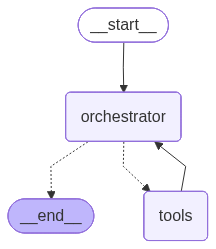

In [34]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [38]:
query = "Is NVDIA overvalued right now?"

messages = [HumanMessage(content=query)]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Is NVDIA overvalued right now?
================================== Ai Message ==================================
Tool Calls:
  detect_financial_stage (call_RAgF5gYQx7IFF1DyY0R1nYj8)
 Call ID: call_RAgF5gYQx7IFF1DyY0R1nYj8
  Args:
    ticker: NVDA
================================= Tool Message =================================
Name: detect_financial_stage

{"ticker": "NVDA", "stage": "profitable_cash_generative", "recommended_tools": ["run_earnings_analysis", "run_cashflow_analysis", "run_revenue_analysis"], "net_income": 120067000000.0, "fcf": 96676000000.0, "revenue_ttm": 215938007040, "note": "Call these tools next: ['run_earnings_analysis', 'run_cashflow_analysis', 'run_revenue_analysis']"}
================================== Ai Message ==================================
Tool Calls:
  run_earnings_analysis (call_tjSNr4ddrM8rkAJNlyryvlTT)
 Call ID: call_tjSNr4ddrM8rkAJNlyryvlTT
  Args:
    ticker: NVDA
  

In [43]:
print(messages['messages'][-1].content)

### Verdict: Fairly Valued with Upside Potential (Confidence: 70%)

**Key Flags:**
- **Earnings Analysis:**
  - **P/E (TTM):** 40.29 (Premium)
  - **Forward P/E:** 17.57 (Reasonable given growth prospects)
  - **PEG Ratio:** 0.42 (Suggests undervaluation relative to growth)
  - **P/B:** 30.51 (Premium to book value)

- **Cash Flow Analysis:**
  - **P/FCF:** 49.64 (Moderate)
  - **EV/EBITDA:** 35.82 (Expensive)
  - **EV/FCF:** 49.36 (Moderate)

- **Revenue Analysis:**
  - **P/S:** 22.22 (Expensive)
  - **EV/Revenue:** 22.1 (Expensive)

- **Analyst Sentiment:**
  - **Recommendation:** Strong Buy
  - **Mean Price Target:** $269.17 (Implied Upside: 36.3%)
  - **Earnings Growth Rate:** 95.6% (Strong growth expectations)

### Summary:
NVIDIA is trading at a premium based on traditional valuation metrics like P/E and P/S, but its PEG ratio indicates that the stock may be undervalued relative to its growth potential. The strong buy recommendation from analysts and significant upside potential 